🚀 POSTER FER - Local Training (VSCode)
Chạy từng cell hoặc chạy toàn bộ file


In [1]:
# ===== STEP 1: Import =====
import os
import sys
import warnings
import gc
import random
import collections
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
from torchvision import transforms
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

warnings.filterwarnings("ignore")




In [2]:
# ===== STEP 2: Cấu hình =====
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, 'data')
PRETRAIN_IR50 = os.path.join(BASE_DIR, 'pretrain', 'ir50.pth')
PRETRAIN_MFN = os.path.join(BASE_DIR, 'pretrain', 'mobilefacenet_model_best.pth.tar')
SAVE_DIR = os.path.join(BASE_DIR, 'checkpoints')

BATCH_SIZE = 16      # 8GB VRAM: 16 an toàn với SAM double forward + AMP
EPOCHS = 100         # 100 epoch đủ để hội tụ trên 8GB setup
LR = 0.00004
NUM_WORKERS = 0      # 0 = không spawn process con, tiết kiệm RAM nhất

os.makedirs(SAVE_DIR, exist_ok=True)
sys.path.insert(0, BASE_DIR)




In [3]:
# ===== STEP 3: Device + GPU Check =====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n{"="*60}')
print(f'  POSTER FER - Local Training')
print(f'{"="*60}')
print(f'  Device     : {device}')
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_mb = torch.cuda.get_device_properties(0).total_memory / 1024**2
    print(f'  GPU        : {gpu_name}')
    print(f'  VRAM       : {vram_mb:.0f}MB')
    # Auto-adjust batch size theo VRAM
    if vram_mb >= 14000:
        BATCH_SIZE = 64
    elif vram_mb >= 7000:
        BATCH_SIZE = 16
    else:
        BATCH_SIZE = 8
    print(f'  Batch Size : {BATCH_SIZE} (auto-adjusted for {vram_mb:.0f}MB VRAM)')
else:
    print(f'  ⚠️  ĐANG CHẠY BẰNG CPU! Training sẽ RẤT CHẬM!')
    print(f'  ⚠️  Nếu máy có GPU NVIDIA, cài PyTorch CUDA:')
    print(f'      pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121')
    print(f'  ⚠️  Hoặc chạy trên Google Colab (có GPU T4 miễn phí)')
    BATCH_SIZE = 16  # CPU không giới hạn VRAM, chỉ giới hạn RAM
print(f'  Epochs     : {EPOCHS}')
print(f'  Data Path  : {DATA_PATH}')
print(f'{"="*60}\n')

# Reproducibility (official code dùng seed=123)
torch.manual_seed(123)
np.random.seed(123)
random.seed(123)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(123)





  POSTER FER - Local Training
  Device     : cuda
  GPU        : NVIDIA GeForce RTX 3070
  VRAM       : 8192MB
  Batch Size : 16 (auto-adjusted for 8192MB VRAM)
  Epochs     : 100
  Data Path  : e:\hoc\cv\data



In [4]:
# ===== STEP 4: Dataset class =====
CLASS_NAMES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
NUM_CLASSES = 7

def add_gaussian_noise(img, mean=0.0, var=30):
    return np.clip(img + np.random.normal(mean, var**0.5, img.shape), 0, 255).astype(np.uint8)

class RafDataSet(data.Dataset):
    """Dataset loader cho RAF-DB."""
    def __init__(self, data_path, train=True, transform=None, basic_aug=False):
        self.transform = transform
        self.train = train
        self.basic_aug = basic_aug

        csv_name = 'train_labels.csv' if train else 'test_labels.csv'
        csv_path = os.path.join(data_path, csv_name)
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f'Không tìm thấy {csv_path}')

        df = pd.read_csv(csv_path)
        file_names = df['image'].values
        labels = df['label'].values
        self.target = np.array(labels - 1)  # 1-7 → 0-6

        split = 'train' if train else 'test'
        self.file_paths = []
        for fname, lbl in zip(file_names, labels):
            path = os.path.join(data_path, 'DATASET', split, str(lbl), fname)
            self.file_paths.append(path)

        found = sum(1 for p in self.file_paths[:20] if os.path.exists(p))
        print(f"  {'Train' if train else 'Test'}: {len(self.file_paths)} samples (checked {found}/20 exist)")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        sample = cv2.imread(self.file_paths[idx])
        if sample is None:
            sample = np.zeros((224, 224, 3), dtype=np.uint8)
        target = self.target[idx]
        if self.train and self.basic_aug and random.random() > 0.5:
            if random.random() > 0.5:
                sample = cv2.flip(sample, 1)
            else:
                sample = add_gaussian_noise(sample)
        if self.transform:
            sample = self.transform(sample.copy())
        return sample, target




In [5]:
# ===== STEP 5: Transforms & DataLoader =====
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224, 224)),
    transforms.RandomApply([transforms.ColorJitter(0.3, 0.3, 0.3, 0.1)], p=0.5),
    transforms.RandomApply([transforms.RandomRotation(10)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.25)),
])
val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print('Loading dataset...')
train_dataset = RafDataSet(DATA_PATH, train=True, transform=train_tf, basic_aug=True)
val_dataset = RafDataSet(DATA_PATH, train=False, transform=val_tf)
train_loader = data.DataLoader(train_dataset, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = data.DataLoader(val_dataset, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)




Loading dataset...
  Train: 12271 samples (checked 20/20 exist)
  Test: 3068 samples (checked 20/20 exist)


In [6]:
# ===== STEP 6: Model =====
from models.ir50 import Backbone
from models.mobilefacenet import MobileFaceNet
from models.hyp_crossvit import HyVisionTransformer

def load_weights(model, ckpt):
    """Load pretrained weights với auto-mapping body1/body2/body3 → body.N"""
    sd = ckpt.get('state_dict', ckpt)
    md = model.state_dict()
    new = collections.OrderedDict()

    # Build mapping: checkpoint body1/2/3.X → model body.N (flat Sequential)
    key_map = {}
    idx = 0
    for group, count in [('body1', 3), ('body2', 4), ('body3', 14)]:
        for i in range(count):
            key_map[f'{group}.{i}.'] = f'body.{idx}.'
            idx += 1

    for k, v in sd.items():
        # Thử nhiều cách strip prefix
        k_clean = k.replace('module.', '')
        # Áp dụng body mapping
        mapped_k = k_clean
        for old_prefix, new_prefix in key_map.items():
            if k_clean.startswith(old_prefix):
                mapped_k = k_clean.replace(old_prefix, new_prefix)
                break
        if mapped_k in md and md[mapped_k].size() == v.size():
            new[mapped_k] = v

    md.update(new)
    model.load_state_dict(md)
    matched = len(new)
    print(f'    ✅ Loaded {matched}/{len(md)} layers (checkpoint has {len(sd)} tensors)')
    if matched < len(md) * 0.5:
        print(f'    ⚠️ WARNING: Only {matched} layers matched!')
    return model

class SE_block(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(d,d), nn.ReLU(), nn.Linear(d,d), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x)

class POSTER(nn.Module):
    def __init__(self, num_classes=7, depth=8):
        super().__init__()
        self.face_landback = MobileFaceNet([112,112], 136)
        self.ir_back = Backbone(50, 0.0, 'ir')
        self.ir_layer = nn.Linear(1024, 512)
        self.pyramid_fuse = HyVisionTransformer(
            in_chans=49, q_chanel=49, embed_dim=512,
            depth=depth, num_heads=8, mlp_ratio=2.,
            drop_rate=0., attn_drop_rate=0., drop_path_rate=0.1)
        self.se_block = SE_block(512)
        self.dropout = nn.Dropout(0.3)
        self.head = nn.Linear(512, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x_face = F.interpolate(x, size=112)
        _, x_face = self.face_landback(x_face)
        x_face = x_face.view(B, -1, 49).transpose(1, 2)
        x_ir = self.ir_layer(self.ir_back(x))
        y = self.se_block(self.pyramid_fuse(x_ir, x_face))
        y = self.dropout(y)
        return self.head(y), y




In [7]:
# ===== STEP 7: Load pretrained weights =====
print('\nBuilding model...')
model = POSTER(NUM_CLASSES, depth=8)

if os.path.exists(PRETRAIN_IR50):
    print('  Loading IR-50 pretrained...')
    ir50_ckpt = torch.load(PRETRAIN_IR50, map_location='cpu')
    load_weights(model.ir_back, ir50_ckpt)
    del ir50_ckpt
else:
    print(f'  ⚠️ Không tìm thấy {PRETRAIN_IR50} - dùng random weights')

if os.path.exists(PRETRAIN_MFN):
    print('  Loading MobileFaceNet pretrained...')
    mfn_ckpt = torch.load(PRETRAIN_MFN, map_location='cpu')
    model.face_landback.load_state_dict(mfn_ckpt['state_dict'])
    del mfn_ckpt
else:
    print(f'  ⚠️ Không tìm thấy {PRETRAIN_MFN} - dùng random weights')

gc.collect()
for p in model.face_landback.parameters():
    p.requires_grad = False

model = model.to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f'  Trainable params: {total_params:.1f}M')
if torch.cuda.is_available():
    print(f'  GPU Memory used : {torch.cuda.memory_allocated()/1024**2:.0f}MB')





Building model...
  Loading IR-50 pretrained...
    ✅ Loaded 292/292 layers (checkpoint has 304 tensors)
  Loading MobileFaceNet pretrained...
  Trainable params: 58.0M
  GPU Memory used : 226MB


In [8]:
# ===== STEP 8: Loss functions + SAM Optimizer =====
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        self.confidence = 1. - smoothing
    def forward(self, x, target):
        logprobs = F.log_softmax(x, dim=-1)
        nll_loss = -logprobs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
        smooth_loss = -logprobs.mean(dim=-1)
        return (self.confidence * nll_loss + self.smoothing * smooth_loss).mean()

class SAM(torch.optim.Optimizer):
    """Sharpness-Aware Minimization - core component của POSTER paper."""
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["old_p"] = p.data.clone()
                e_w = (torch.pow(p, 2) if group["adaptive"] else 1.0) * p.grad * scale.to(p)
                p.add_(e_w)
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.data = self.state[p]["old_p"]
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        return torch.norm(torch.stack([
            ((torch.abs(p) if group["adaptive"] else 1.0) * p.grad).norm(p=2).to(shared_device)
            for group in self.param_groups for p in group["params"] if p.grad is not None
        ]), p=2)




In [9]:
# ===== STEP 9: Training Loop (SAM + AMP) =====
from tqdm.auto import tqdm

# ✅ SAM optimizer giống official code
optimizer = SAM(model.parameters(), torch.optim.Adam, lr=LR, rho=0.05, adaptive=False)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.98)
CE_criterion = nn.CrossEntropyLoss()
lsce_criterion = LabelSmoothingCrossEntropy(smoothing=0.2)
best_acc = 0
history = {'ta':[], 'va':[], 'tl':[], 'vl':[]}

use_amp = torch.cuda.is_available()
# Không dùng GradScaler vì SAM cần gọi unscale_ 2 lần (không tương thích)
# autocast alone vẫn cho tốc độ nhanh trên RTX 3070

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

total_batches_train = len(train_loader)
total_batches_val = len(val_loader)

print(f'\n{"="*60}')
print(f'  BẮT ĐẦU TRAINING - {EPOCHS} epochs')
print(f'  Train batches: {total_batches_train} | Val batches: {total_batches_val}')
print(f'{"="*60}')
sys.stdout.flush()

for epoch in range(1, EPOCHS+1):
    model.train()
    tloss, tcorr, cnt = 0, 0, 0
    t0 = time()

    # Training với SAM double forward-backward
    pbar = tqdm(train_loader, desc=f'Epoch {epoch:03d}/{EPOCHS} [Train]',
                leave=False, ncols=100, bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
    for imgs, tgts in pbar:
        cnt += 1
        imgs, tgts = imgs.to(device), tgts.to(device)

        # SAM First Forward-Backward
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=use_amp):
            out, feat = model(imgs)
            loss = 2*lsce_criterion(out, tgts) + CE_criterion(out, tgts)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        # SAM Second Forward-Backward
        with torch.amp.autocast('cuda', enabled=use_amp):
            out2, feat2 = model(imgs)
            loss2 = 2*lsce_criterion(out2, tgts) + CE_criterion(out2, tgts)
        loss2.backward()
        optimizer.second_step(zero_grad=True)

        tloss += loss2.item()
        tcorr += (out2.argmax(1)==tgts).sum().item()

        pbar.set_postfix({'loss': f'{tloss/cnt:.4f}', 'acc': f'{tcorr/(cnt*BATCH_SIZE)*100:.1f}%'})
        del out, out2, feat, feat2, loss, loss2
    pbar.close()

    ta = tcorr/len(train_dataset)
    tl = tloss/cnt

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    # Validation với progress bar
    model.eval()
    vloss, vcorr, vcnt = 0, 0, 0
    preds_all, tgts_all = [], []

    # Validation
    pbar_val = tqdm(val_loader, desc=f'Epoch {epoch:03d}/{EPOCHS} [Val  ]',
                    leave=False, ncols=100, bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
    with torch.no_grad():
        for imgs, tgts in pbar_val:
            imgs, tgts = imgs.to(device), tgts.to(device)
            with torch.amp.autocast('cuda', enabled=use_amp):
                out, _ = model(imgs)
                vloss += CE_criterion(out, tgts).item(); vcnt += 1
            p = out.argmax(1)
            vcorr += (p==tgts).sum().item()
            preds_all.extend(p.cpu().tolist())
            tgts_all.extend(tgts.cpu().tolist())
            del out, p
    pbar_val.close()

    va = vcorr/len(val_dataset)
    vl = vloss/vcnt
    f1 = f1_score(tgts_all, preds_all, average='macro')
    history['ta'].append(ta); history['va'].append(va)
    history['tl'].append(tl); history['vl'].append(vl)

    elapsed = (time()-t0)/60
    mem_used = torch.cuda.memory_allocated()/1024**2 if torch.cuda.is_available() else 0

    # In kết quả ngay lập tức
    star = ' ★★★ NEW BEST' if va > best_acc else ''
    print(f'\n  ┌─── EPOCH {epoch:02d}/{EPOCHS}  |  {elapsed:.1f} phút  |  GPU: {mem_used:.0f}MB')
    print(f'  │  Train Loss : {tl:.4f}    Train Acc : {ta*100:6.2f}%')
    print(f'  │  Val Loss   : {vl:.4f}    Val Acc   : {va*100:6.2f}%')
    print(f'  │  Val F1     : {f1:.4f}    LR        : {optimizer.param_groups[0]["lr"]:.6f}')

    scheduler.step()

    if va > best_acc:
        best_acc = va
        save_path = os.path.join(SAVE_DIR, 'poster_best.pth')
        torch.save(model.state_dict(), save_path)
        print(f'  │  ★★★ NEW BEST: {best_acc*100:.2f}% → saved!')
    print(f'  └─── Best so far: {best_acc*100:.2f}%{star}')
    sys.stdout.flush()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()





  BẮT ĐẦU TRAINING - 100 epochs
  Train batches: 767 | Val batches: 192



  ┌─── EPOCH 01/100  |  6.7 phút  |  GPU: 709MB
  │  Train Loss : 3.9851    Train Acc :  61.14%
  │  Val Loss   : 0.5952    Val Acc   :  83.67%
  │  Val F1     : 0.7091    LR        : 0.000040
  │  ★★★ NEW BEST: 83.67% → saved!
  └─── Best so far: 83.67% ★★★ NEW BEST



  ┌─── EPOCH 02/100  |  6.0 phút  |  GPU: 715MB
  │  Train Loss : 3.3147    Train Acc :  72.97%
  │  Val Loss   : 0.5289    Val Acc   :  86.38%
  │  Val F1     : 0.7627    LR        : 0.000039
  │  ★★★ NEW BEST: 86.38% → saved!
  └─── Best so far: 86.38% ★★★ NEW BEST



  ┌─── EPOCH 03/100  |  6.0 phút  |  GPU: 713MB
  │  Train Loss : 3.0960    Train Acc :  76.55%
  │  Val Loss   : 0.4922    Val Acc   :  87.26%
  │  Val F1     : 0.7960    LR        : 0.000038
  │  ★★★ NEW BEST: 87.26% → saved!
  └─── Best so far: 87.26% ★★★ NEW BEST



  ┌─── EPOCH 04/100  |  5.9 phút  |  GPU: 713MB
  │  Train Loss : 2.9409    Train Acc :  79.28%
  │  Val Loss   : 0.4638    Val Acc   :  87.19%
  │  Val F1     : 0.7985    LR        : 0.000038
  └─── Best so far: 87.26%


...


  ┌─── EPOCH 96/100  |  5.8 phút  |  GPU: 710MB
  │  Train Loss : 1.7605    Train Acc :  98.67%
  │  Val Loss   : 0.3763    Val Acc   :  90.65%
  │  Val F1     : 0.8530    LR        : 0.000006
  └─── Best so far: 91.13%



  ┌─── EPOCH 97/100  |  5.8 phút  |  GPU: 709MB
  │  Train Loss : 1.7613    Train Acc :  98.56%
  │  Val Loss   : 0.3743    Val Acc   :  90.61%
  │  Val F1     : 0.8545    LR        : 0.000006
  └─── Best so far: 91.13%



  ┌─── EPOCH 98/100  |  5.8 phút  |  GPU: 710MB
  │  Train Loss : 1.7542    Train Acc :  98.75%
  │  Val Loss   : 0.3770    Val Acc   :  90.71%
  │  Val F1     : 0.8556    LR        : 0.000006
  └─── Best so far: 91.13%



  ┌─── EPOCH 99/100  |  5.8 phút  |  GPU: 709MB
  │  Train Loss : 1.7546    Train Acc :  98.77%
  │  Val Loss   : 0.3776    Val Acc   :  90.71%
  │  Val F1     : 0.8548    LR        : 0.000006
  └─── Best so far: 91.13%



  ┌─── EPOCH 100/100  |  5.9 phút  |  GPU: 710MB
  │  Train Loss : 1.7478    Train Acc :  98.78%
  │  Val Loss   : 0.3768    Val Acc   :  90.71%
  │  Val F1     : 0.8506    LR        : 0.000005
  └─── Best so far: 91.13%



  ĐÁNH GIÁ TRÊN TẬP TEST

  PER-CLASS ACCURACY
  ────────────────────────────────────────
    Surprise    :  90.88%
    Fear        :  59.46%
    Disgust     :  79.38%
    Happiness   :  96.71%
    Sadness     :  91.21%
    Anger       :  84.57%
    Neutral     :  89.26%

    Mean Class  : 84.50%
    Overall     : 91.13%

              precision    recall  f1-score   support

    Surprise     0.9006    0.9088    0.9047       329
        Fear     0.8800    0.5946    0.7097        74
     Disgust     0.7697    0.7937    0.7815       160
   Happiness     0.9655    0.9671    0.9663      1185
     Sadness     0.8651    0.9121    0.8880       478
       Anger     0.9133    0.8457    0.8782       162
     Neutral     0.8926    0.8926    0.8926       680

    accuracy                         0.9113      3068
   macro avg     0.8838    0.8450    0.8601      3068
weighted avg     0.9117    0.9113    0.9107      3068


  ✅ Confusion matrix saved to e:\hoc\cv\checkpoints/confusion_matrix.png


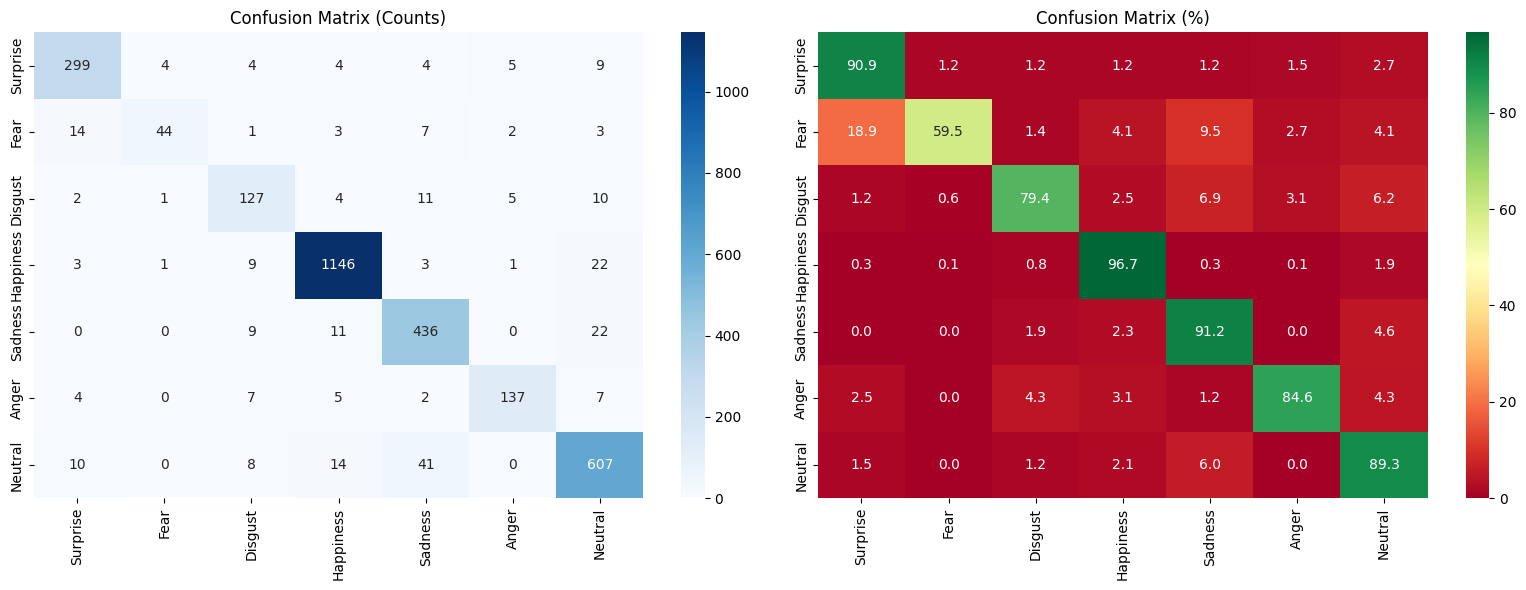

  ✅ Training curves saved to e:\hoc\cv\checkpoints/training_curves.png


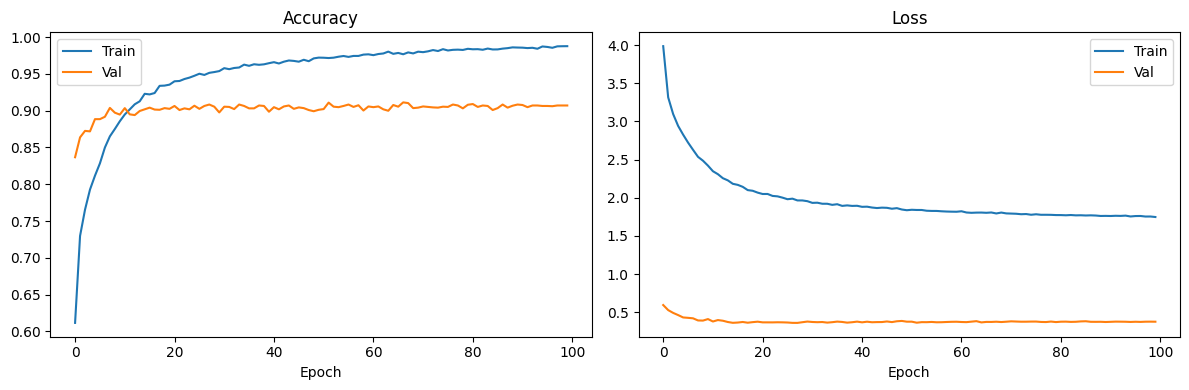


  🎉 HOÀN THÀNH! Best Val Acc: 91.13%


In [10]:
# ===== STEP 10: Evaluation =====
print(f'\n{"="*60}')
print(f'  ĐÁNH GIÁ TRÊN TẬP TEST')
print(f'{"="*60}')

best_path = os.path.join(SAVE_DIR, 'poster_best.pth')
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=device))

model.eval()
preds_all, tgts_all = [], []
with torch.no_grad():
    for imgs, tgts in val_loader:
        with torch.amp.autocast('cuda', enabled=use_amp):
            out, _ = model(imgs.to(device))
        preds_all.extend(out.argmax(1).cpu().tolist())
        tgts_all.extend(tgts.tolist())
        del out
P, T = np.array(preds_all), np.array(tgts_all)

# Per-Class Accuracy
print(f'\n  PER-CLASS ACCURACY')
print(f'  {"─"*40}')
pc = []
for i in range(NUM_CLASSES):
    m = T==i
    a = (P[m]==i).sum()/m.sum()*100
    pc.append(a)
    print(f'    {CLASS_NAMES[i]:12s}: {a:6.2f}%')
print(f'\n    Mean Class  : {np.mean(pc):.2f}%')
print(f'    Overall     : {(P==T).sum()/len(T)*100:.2f}%')

# Classification Report
print(f'\n{classification_report(T, P, target_names=CLASS_NAMES, digits=4)}')

# Confusion Matrix
cm = confusion_matrix(T, P)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[0])
ax[0].set_title('Confusion Matrix (Counts)')
cm_n = cm / cm.sum(1, keepdims=True) * 100
sns.heatmap(cm_n, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax[1])
ax[1].set_title('Confusion Matrix (%)')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150)
print(f'\n  ✅ Confusion matrix saved to {SAVE_DIR}/confusion_matrix.png')
plt.show()

# Training Curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['ta'], label='Train'); ax[0].plot(history['va'], label='Val')
ax[0].set_title('Accuracy'); ax[0].set_xlabel('Epoch'); ax[0].legend()
ax[1].plot(history['tl'], label='Train'); ax[1].plot(history['vl'], label='Val')
ax[1].set_title('Loss'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
print(f'  ✅ Training curves saved to {SAVE_DIR}/training_curves.png')
plt.show()

print(f'\n  🎉 HOÀN THÀNH! Best Val Acc: {best_acc*100:.2f}%')

